In [52]:
import keras.models as models
import pandas as pd
data_set=pd.read_csv('concrete.csv')


In [53]:
data_set.head()

,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Age,CompressiveStrength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [54]:
data_set.isnull().sum()

Cement                 0
BlastFurnaceSlag       0
FlyAsh                 0
Water                  0
Superplasticizer       0
CoarseAggregate        0
FineAggregate          0
Age                    0
CompressiveStrength    0
dtype: int64

In [55]:
ds=data_set.values

In [56]:
data=ds[:,0:8]
target=ds[:,8]

In [57]:
print(data)

[[ 540.     0.     0.  ... 1040.   676.    28. ]
 [ 540.     0.     0.  ... 1055.   676.    28. ]
 [ 332.5  142.5    0.  ...  932.   594.   270. ]
 ...
 [ 148.5  139.4  108.6 ...  892.4  780.    28. ]
 [ 159.1  186.7    0.  ...  989.6  788.9   28. ]
 [ 260.9  100.5   78.3 ...  864.5  761.5   28. ]]


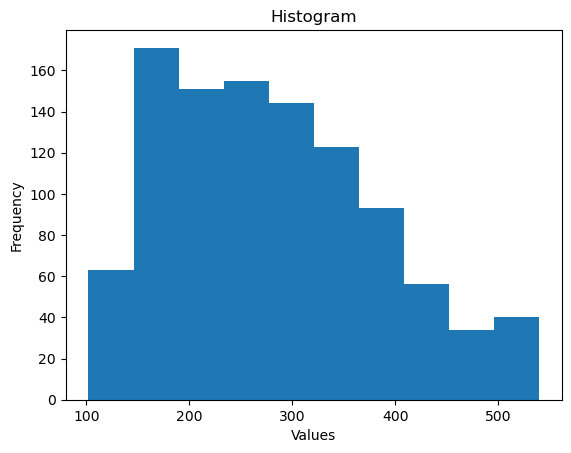

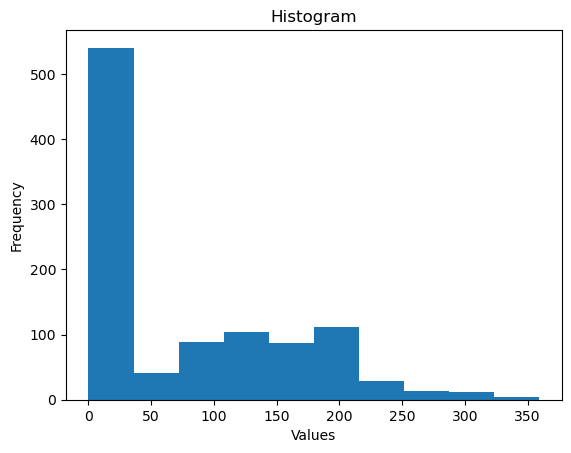

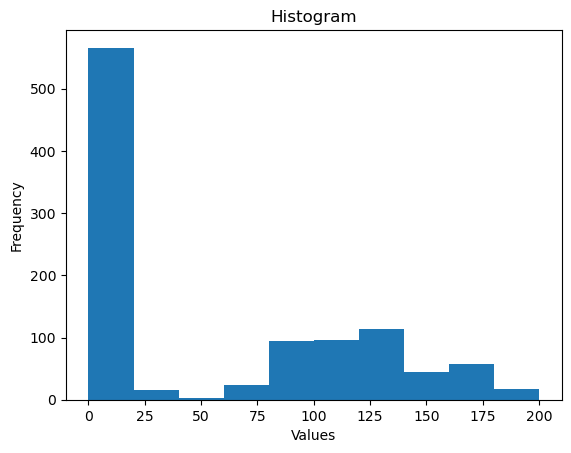

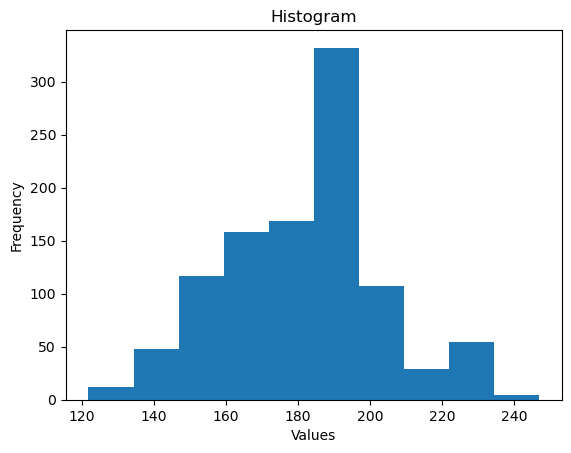

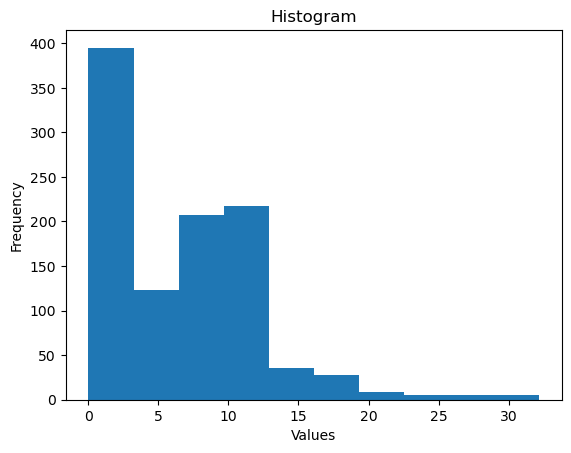

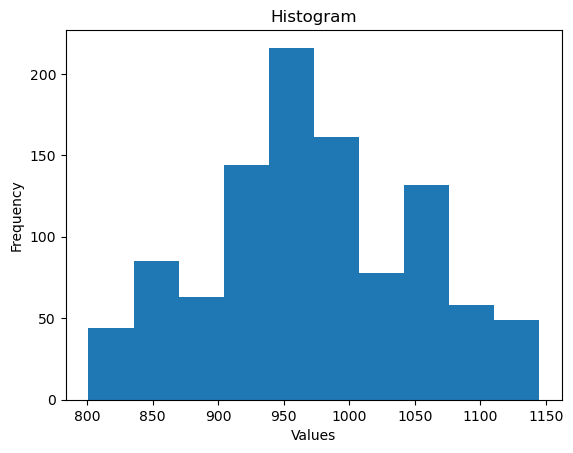

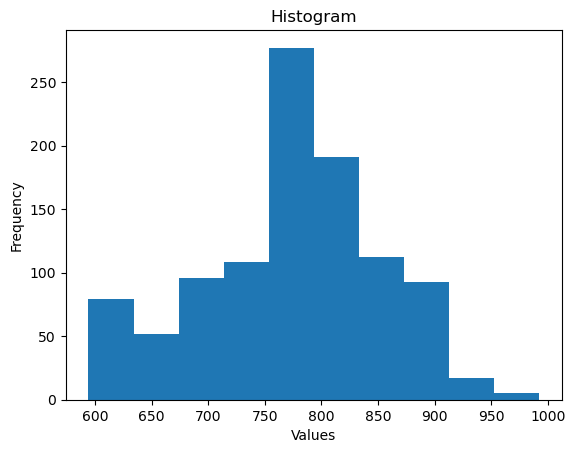

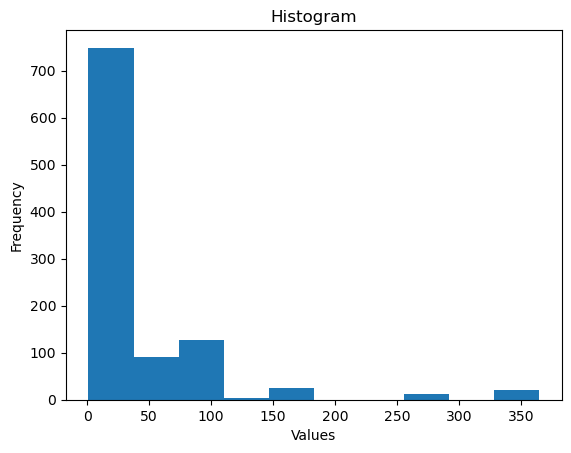

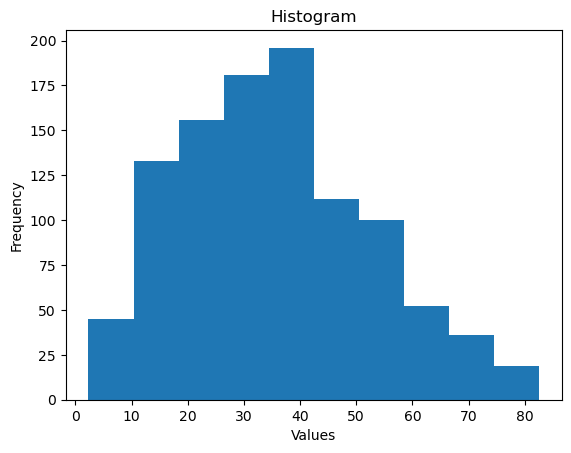

In [58]:
import matplotlib.pyplot as plt
for i in range(ds.shape[1]):
    plt.hist(ds[:,i])
    plt.xlabel('Values')
    plt.ylabel('Frequency')
    plt.title('Histogram')
    plt.show()


In [59]:
from sklearn.preprocessing import MinMaxScaler 
import numpy as np
target=np.reshape(target,(-1,1))
scaler_data= MinMaxScaler()
scaler_target=MinMaxScaler()

data_scaled=scaler_data.fit_transform(data)
target_scaled=scaler_target.fit_transform(target)

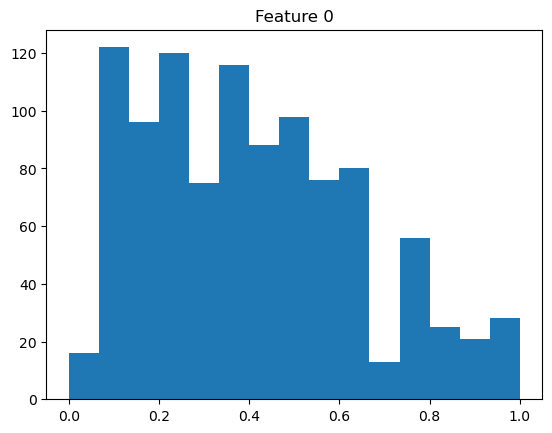

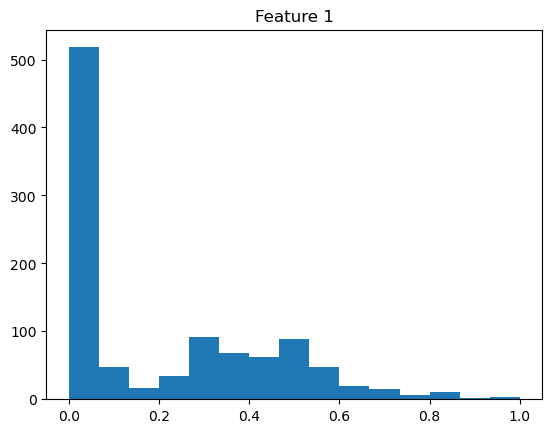

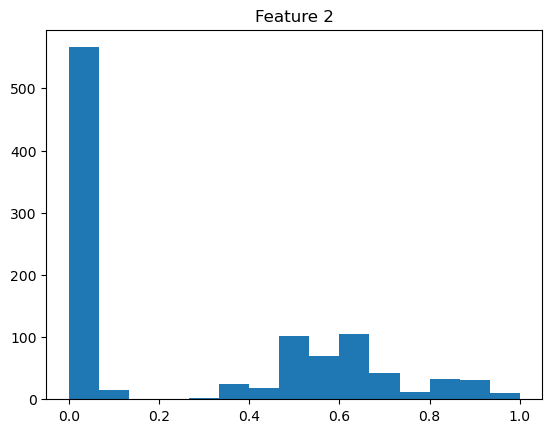

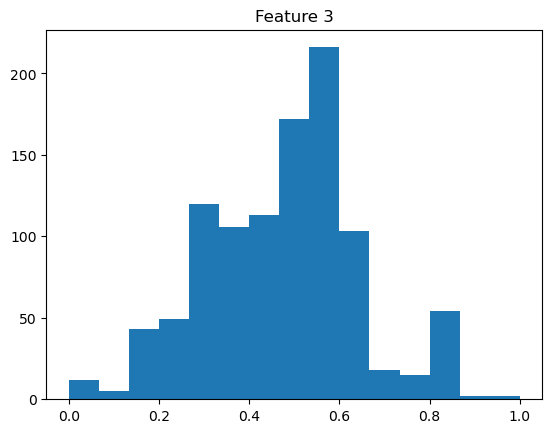

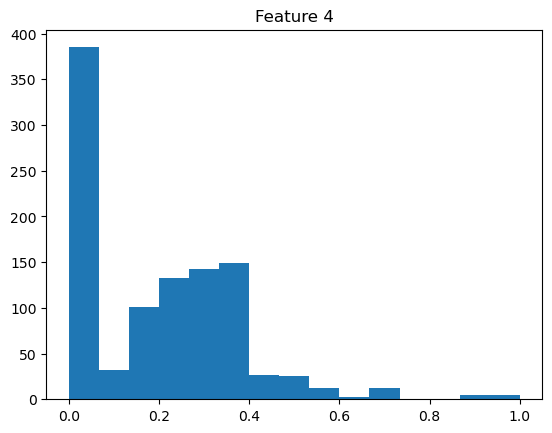

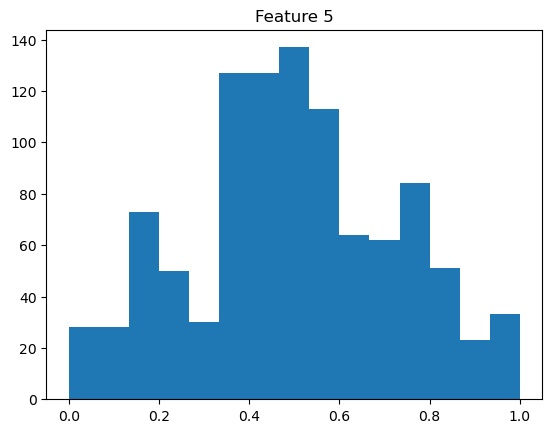

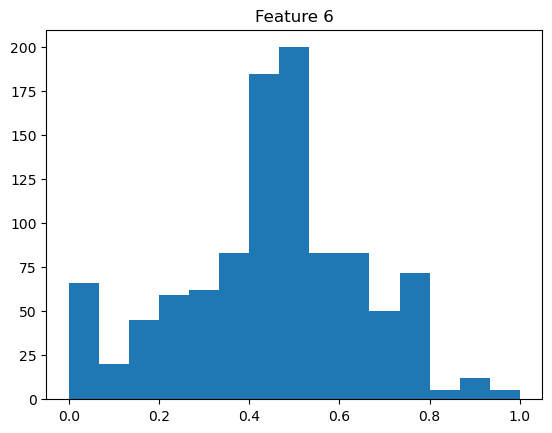

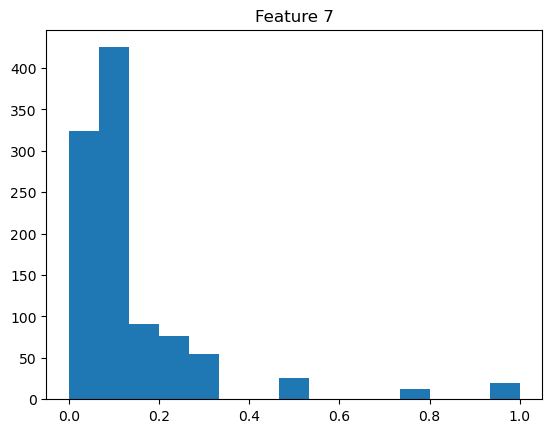

In [60]:
for i in range(data_scaled.shape[1]):
    plt.hist(data_scaled[:, i], bins=15)
    plt.title(f'Feature {i}')
    plt.show()


In [61]:
from sklearn.model_selection import train_test_split
train_data,test_data,train_target,test_target=train_test_split(data_scaled,target_scaled,test_size=0.2)


In [62]:
from keras.models import Sequential
from keras.layers import Dense,Dropout
import numpy as np

from keras.optimizers import Adam,Adagrad,Adadelta
def build_model(parameters):
    model = Sequential()
    for i in range (parameters.Int('num_layers',2,20)):
        if(i==0):
            model.add(Dense(units=parameters.Int('#neurons layer' + str(i),min_value=32,max_value=512,step=32),
                            activation=parameters.Choice('activation_function' +str(i),['relu','sigmoid','tanh']),input_dim=8))
            model.add(Dropout(parameters.Choice('drop_prob 1',[0.2,0.3,0.4,0.5])))
        else:
            model.add(Dense(units=parameters.Int('#neurons layer' + str(i),min_value=32,max_value=512,step=32),
                           activation=parameters.Choice('activation_function' +str(i),['relu','sigmoid','tanh'])))
            model.add(Dropout(parameters.Choice('drop_prob 2',[0.2,0.3,0.4,0.5])))
    model.add(Dense(1,activation='linear'))

    model.compile(optimizer=parameters.Choice('optmz',['adam','adaDelta','adaGrad']),loss='mse')
    return model

In [63]:
from kerastuner.tuners import RandomSearch
tuner = RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5,
    executions_per_trial=3,
    directory='project',
    project_name='concrete'
)


Reloading Tuner from project\concrete\tuner0.json


In [64]:
tuner.search_space_summary()


Search space summary
Default search space size: 36
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 2, 'max_value': 20, 'step': 1, 'sampling': 'linear'}
#neurons layer0 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 512, 'step': 32, 'sampling': 'linear'}
activation_function0 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'sigmoid', 'tanh'], 'ordered': False}
drop_prob 1 (Choice)
{'default': 0.2, 'conditions': [], 'values': [0.2, 0.3, 0.4, 0.5], 'ordered': True}
#neurons layer1 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 512, 'step': 32, 'sampling': 'linear'}
activation_function1 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'sigmoid', 'tanh'], 'ordered': False}
drop_prob 2 (Choice)
{'default': 0.2, 'conditions': [], 'values': [0.2, 0.3, 0.4, 0.5], 'ordered': True}
optmz (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'adaDelta', 'adaGrad'], 'ordered': False}
#n

In [65]:
tuner.search(train_data,train_target,epochs=10,validation_data=(test_data,test_target))

In [66]:
tuner.results_summary()

Results summary
Results in project\concrete
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 4 summary
Hyperparameters:
num_layers: 4
#neurons layer0: 192
activation_function0: relu
drop_prob 1: 0.4
#neurons layer1: 32
activation_function1: relu
drop_prob 2: 0.2
optmz: adam
#neurons layer2: 320
activation_function2: sigmoid
#neurons layer3: 192
activation_function3: relu
#neurons layer4: 288
activation_function4: sigmoid
#neurons layer5: 32
activation_function5: tanh
#neurons layer6: 416
activation_function6: tanh
#neurons layer7: 32
activation_function7: tanh
#neurons layer8: 512
activation_function8: sigmoid
#neurons layer9: 96
activation_function9: sigmoid
#neurons layer10: 96
activation_function10: relu
#neurons layer11: 320
activation_function11: sigmoid
#neurons layer12: 160
activation_function12: tanh
#neurons layer13: 384
activation_function13: sigmoid
#neurons layer14: 64
activation_function14: sigmoid
#neurons layer15: 416
activation_function15: sigmo

In [67]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best number of layers:", best_hps.get('num_layers'))


Best number of layers: 4


In [68]:
best_model = tuner.hypermodel.build(best_hps)


C:\Users\mhjha\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [69]:
best_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                     │ (None, 192)                 │           1,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 192)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 32)                  │           6,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 320)                 │          10,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 320)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 192)                 │          61,632 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 192)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 1)                   │             193 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 80,289 (313.63 KB)

 Trainable params: 80,289 (313.63 KB)

 Non-trainable params: 0 (0.00 B)

In [70]:
history = best_model.fit(
    train_data,
    train_target,
    epochs=200,
    validation_data=(test_data, test_target),
   
)


Epoch 1/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.3904 - val_loss: 0.0815
Epoch 2/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1411 - val_loss: 0.0480
Epoch 3/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0895 - val_loss: 0.0378
Epoch 4/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0624 - val_loss: 0.0329
Epoch 5/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0486 - val_loss: 0.0304
Epoch 6/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0398 - val_loss: 0.0385
Epoch 7/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0379 - val_loss: 0.0408
Epoch 8/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0333 - val_loss: 0.0309
Epoch 9/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0299 - val_loss: 0.0288
Epoch 10/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0259 - val_loss: 0.0242
Epoch 11/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0269 - val_loss: 0.0235
Epoch 12/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.

In [71]:
loss = best_model.evaluate(test_data, test_target)
print("Test Loss:", loss)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0047 
Test Loss: 0.004696281626820564


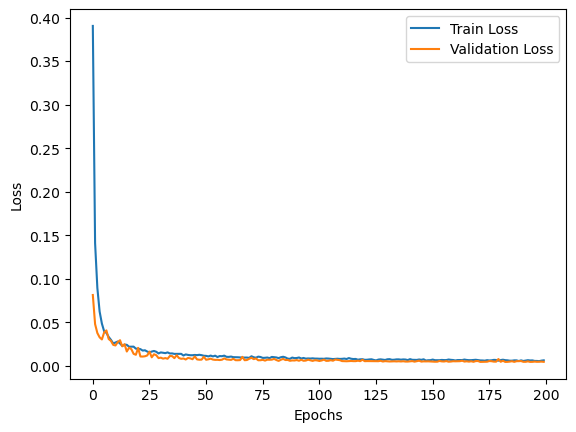

In [72]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [73]:
best_model.save("concrete-quality.keras")
import joblib
joblib.dump(scaler_target, "scaler_target.pkl")
joblib.dump(scaler_data, "scaler_data.pkl")

['scaler_data.pkl']